In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
df = pd.read_csv('data.csv')
print(df.head(10))

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2
5  2018-01-04      1  address_0    product_5           2
6  2018-01-04      1  address_0    product_6           0
7  2018-01-04      1  address_0    product_7           1
8  2018-01-04      1  address_0    product_8           1
9  2018-01-04      1  address_0    product_9           0


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 20.0 MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[us]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  str           
 3   Номенклатура  301355 non-null  str           
 4   Количество    301355 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 17.2 MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
grouped_df = grouped_df.rename(columns={'Количество': 'Количество продаж'})

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head(10)

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055
5,2018-01-10,3653
6,2018-01-11,3176
7,2018-01-12,3092
8,2018-01-13,3294
9,2018-01-14,3228


Нарисуйте график продаж у `grouped_df`

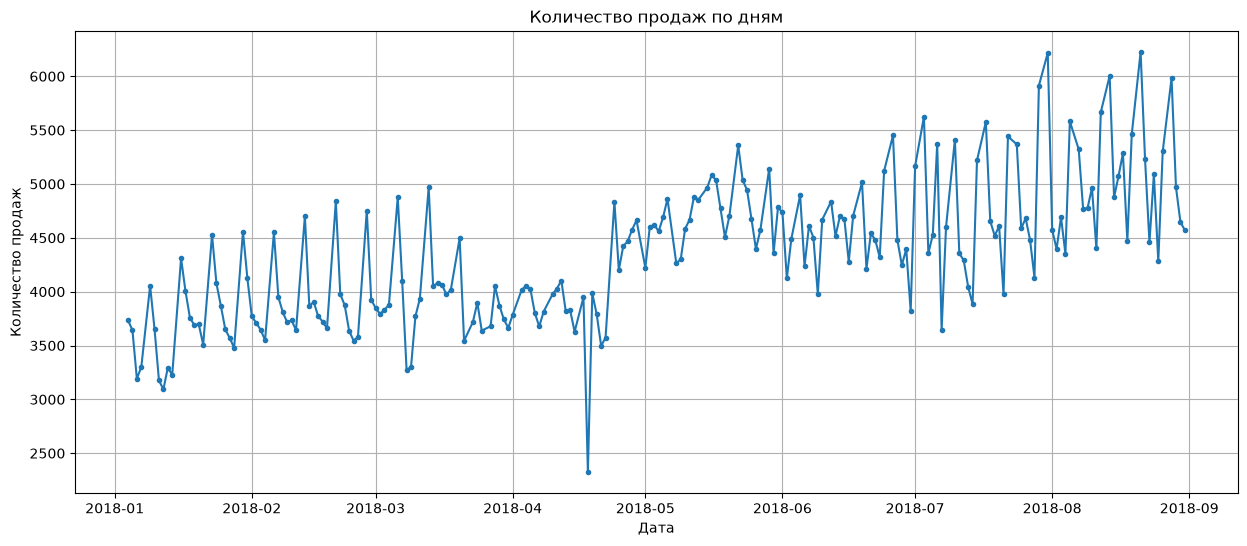

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], marker='o', markersize=3)
plt.title('Количество продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

1. Период данных: с 4 января по 31 августа 2018 года (205 дней продаж).
2. Общий тренд - восходящий: продажи растут от зимы к лету.
   Среднее в день: январь ≈ 3716, февраль ≈ 3910, март ≈ 3926, апрель ≈ 3953,
   май ≈ 4720, июнь ≈ 4540, июль ≈ 4794, август ≈ 5016.
3. Резкий скачок продаж виден в мае - уровень вырос примерно на 20% по сравнению с апрелем.
4. Есть недельная сезонность: график «пилообразный». По понедельникам продаж нет
   (в данных отсутствуют все понедельники), а во вторник - пик (в среднем ≈ 4911),
   так как накапливается спрос за понедельник. Самый слабый день - суббота (≈ 3978).
5. Среднее количество продаж в день ≈ 4339, медиана ≈ 4319, стандартное отклонение ≈ 648.
6. Минимум - 18 апреля 2018 (2326 продаж), это аномальный провал.
7. Максимум - 21 августа 2018 (6226 продаж); самые высокие значения - конец июля и август.
8. Вывод: продажи стабильно растут, имеют выраженную недельную цикличность
   и летний пик; есть единичные выбросы (провал 18 апреля).

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
print(df['Количество'].describe())

max_outlier = df.loc[df['Количество'].idxmax()]
print('\nСтрока с максимальным выбросом:')
print(max_outlier)

Q1 = df['Количество'].quantile(0.25)
Q3 = df['Количество'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[df['Количество'] > Q3 + 1.5 * IQR]
print('\nКоличество выбросов:', len(outliers))
outliers.sort_values('Количество', ascending=False).head()

count    301355.000000
mean          2.951559
std           2.998154
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         200.000000
Name: Количество, dtype: float64

Строка с максимальным выбросом:
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Количество выбросов: 13140


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200
260398,2018-07-31,4,address_125,product_1,140
260399,2018-07-31,4,address_125,product_2,100
258867,2018-07-29,4,address_142,product_1,80
258868,2018-07-29,4,address_142,product_2,70


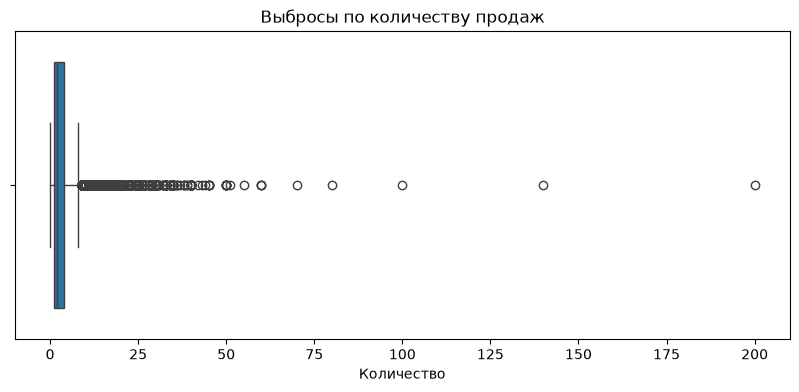

In [10]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Количество'])
plt.title('Выбросы по количеству продаж')
plt.show()

Ответ: 28.06.2018, склад 1, address_208, product_0, количество 200.

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
filtered = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.dayofweek == 2) &          # 2 = среда
    (df['Дата'].dt.month.isin([6, 7, 8]))     # июнь, июль, август
]

top_products = filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)
print(top_products.head())
print('Топовый товар:', top_products.idxmax(), '—', top_products.max(), 'шт.')

Номенклатура
product_1    2267
product_2    2060
product_0    1324
product_3     914
product_6     650
Name: Количество, dtype: int64
Топовый товар: product_1 — 2267 шт.


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [12]:
import os
print(os.getcwd())

C:\Users\User\ACADEMICA HWs


In [13]:
# Задание 11.1. Преобразование данных погоды: Дата и Средняя температура за день,
# объединение с grouped_df
weather = pd.read_csv('weather.csv.gz.csv', sep=';', comment='#',
                      index_col=False, encoding='utf-8')

weather = weather.iloc[:, [0, 1]]
weather.columns = ['Дата', 'T']

weather['Дата'] = pd.to_datetime(weather['Дата'], format='%d.%m.%Y %H:%M').dt.normalize()
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

temp_df = weather.groupby('Дата')['T'].mean().round(1).reset_index()
print(temp_df.head())

merged_df = grouped_df.merge(temp_df, on='Дата', how='left')
merged_df.head()

        Дата     T
0 2018-01-01  -9.5
1 2018-01-02  -9.5
2 2018-01-03 -11.5
3 2018-01-04 -14.1
4 2018-01-05 -16.9


,Дата,Количество продаж,T
0,2018-01-04,3734,-14.1
1,2018-01-05,3643,-16.9
2,2018-01-06,3193,-13.3
3,2018-01-07,3298,-12.8
4,2018-01-09,4055,-6.2


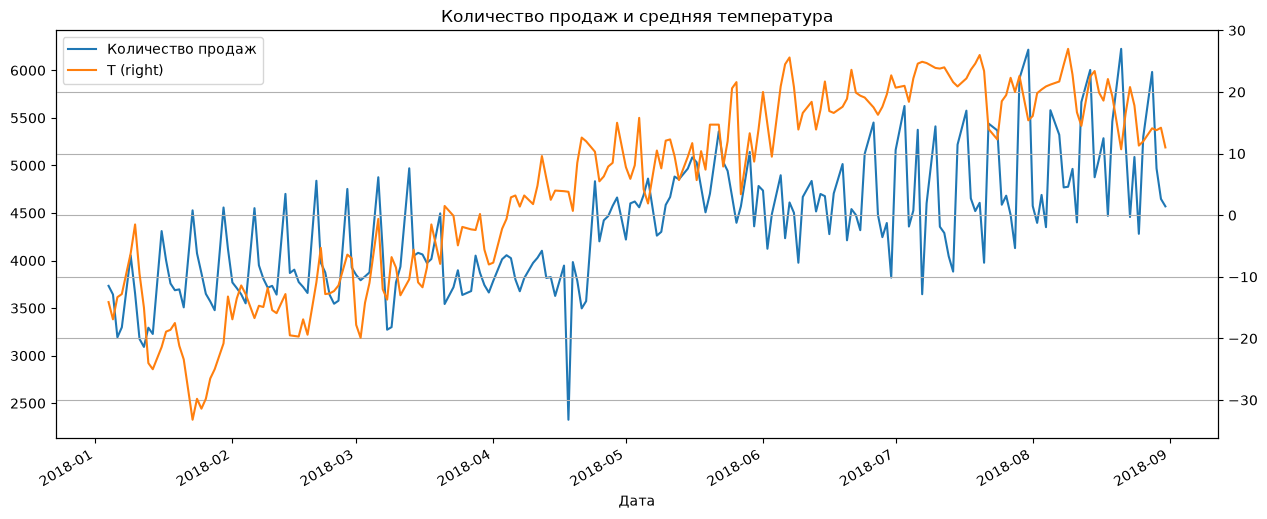

In [14]:
# Задание 11.2. График y=['Количество продаж', 'T']
merged_df.plot(x='Дата', y=['Количество продаж', 'T'],
               secondary_y='T', figsize=(15, 6), grid=True,
               title='Количество продаж и средняя температура')
plt.show()

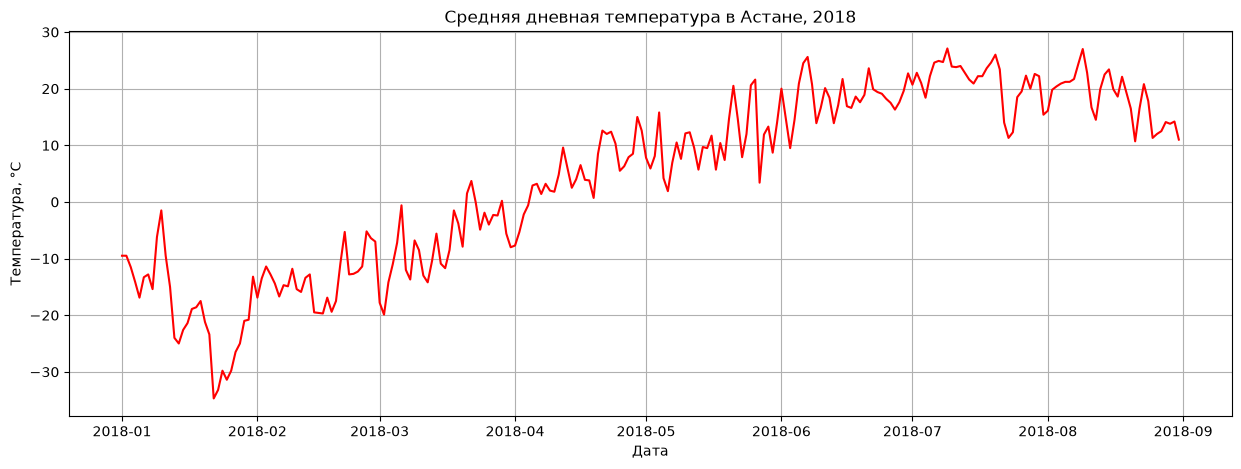

In [15]:
# Задание 11.3. Отдельный график температуры
plt.figure(figsize=(15, 5))
plt.plot(temp_df['Дата'], temp_df['T'], color='red')
plt.title('Средняя дневная температура в Астане, 2018')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()